In [55]:
import yfinance as yf
import plotly.offline as pyo
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sn

pyo.init_notebook_mode(connected=True)
pd.options.plotting.backend = 'plotly'

In [57]:
stocklist = ['GC=F', '^NSEI']
stocklist

['GC=F', '^NSEI']

In [59]:
df = yf.download(stocklist, start='2010-01-01', end='2026-01-27')
df

[*********************100%***********************]  2 of 2 completed


Price             Close                       High                        Low  \
Ticker             GC=F         ^NSEI         GC=F         ^NSEI         GC=F   
Date                                                                            
2010-01-04  1117.699951   5232.200195  1122.300049   5238.450195  1097.099976   
2010-01-05  1118.099976   5277.899902  1126.500000   5288.350098  1115.000000   
2010-01-06  1135.900024   5281.799805  1139.199951   5310.850098  1120.699951   
2010-01-07  1133.099976   5263.100098  1133.099976   5302.549805  1129.199951   
2010-01-08  1138.199951   5244.750000  1138.199951   5276.750000  1122.699951   
...                 ...           ...          ...           ...          ...   
2026-01-20  4759.600098  25232.500000  4764.000000  25585.000000  4661.799805   
2026-01-21  4831.799805  25157.500000  4872.299805  25300.949219  4771.500000   
2026-01-22  4908.799805  25289.900391  4908.799805  25435.750000  4791.899902   
2026-01-23  4976.200195  25048.650391  4976.200195  25347.949219  4936.000000   
2026-01-26  5079.700195           NaN  5095.600098           NaN  5052.200195   

Price                            Open                Volume            
Ticker             ^NSEI         GC=F         ^NSEI    GC=F     ^NSEI  
Date                                                                   
2010-01-04   5167.100098  1117.699951   5200.899902   184.0       0.0  
2010-01-05   5242.399902  1118.099976   5277.149902    53.0       0.0  
2010-01-06   5260.049805  1135.900024   5278.149902   363.0       0.0  
2010-01-07   5244.750000  1133.099976   5281.799805    56.0       0.0  
2010-01-08   5234.700195  1138.199951   5264.250000    54.0       0.0  
...                  ...          ...           ...     ...       ...  
2026-01-20  25171.349609  4662.200195  25580.300781   175.0  409800.0  
2026-01-21  24919.800781  4863.500000  25141.000000  1706.0  395600.0  
2026-01-22  25168.500000  4791.899902  25344.150391  1175.0  486400.0  
2026-01-23  25025.300781  4949.600098  25344.599609   169.0  393900.0  
2026-01-26           NaN  5081.500000           NaN   180.0       NaN  

[4151 rows x 10 columns]

In [61]:
df.Close.dropna()

Ticker,GC=F,^NSEI
Date,,
2010-01-04,1117.699951,5232.200195
2010-01-05,1118.099976,5277.899902
2010-01-06,1135.900024,5281.799805
2010-01-07,1133.099976,5263.100098
2010-01-08,1138.199951,5244.750000
...,...,...
2026-01-16,4588.399902,25694.349609
2026-01-20,4759.600098,25232.500000
2026-01-21,4831.799805,25157.500000


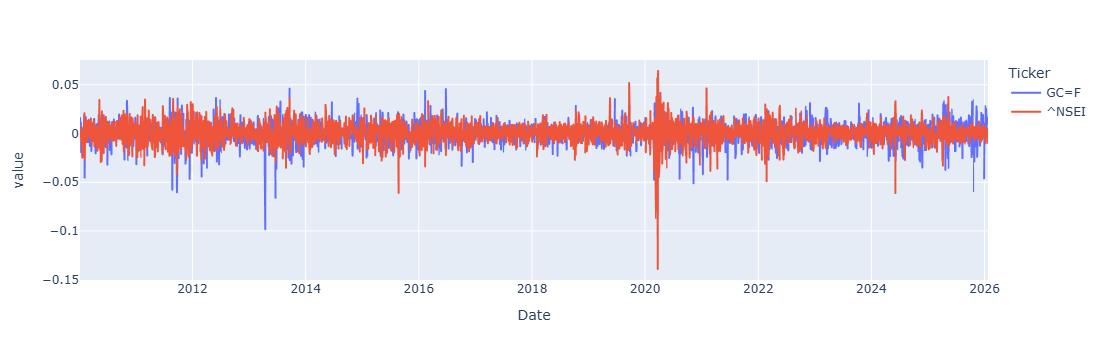

In [63]:
log_returns = np.log(df.Close/df.Close.shift(1)).dropna()
log_returns.plot()

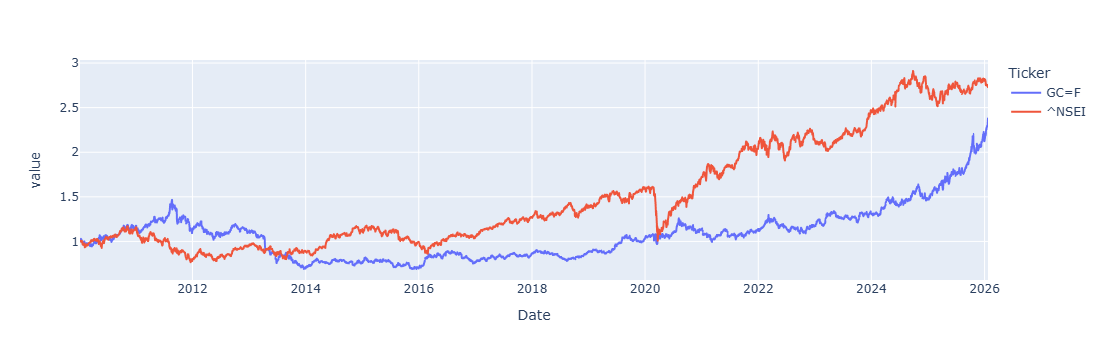

In [65]:
daily_cum_returns = (log_returns + 1).cumprod()
daily_cum_returns.plot()

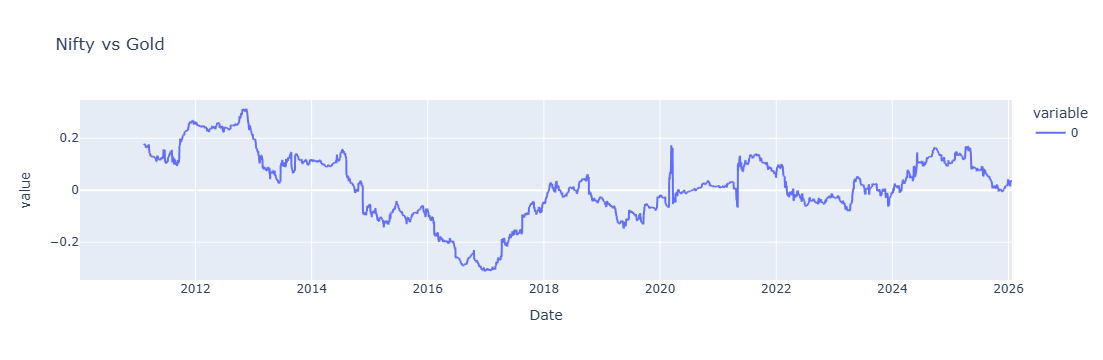

In [67]:
rolling_corr = log_returns['^NSEI'].rolling(252).corr(log_returns['GC=F'])
rolling_corr.plot(title='Nifty vs Gold')

In [69]:
nifty_gold_corr = log_returns['^NSEI'].corr(log_returns['GC=F'])
nifty_gold_corr

0.039240221979096525

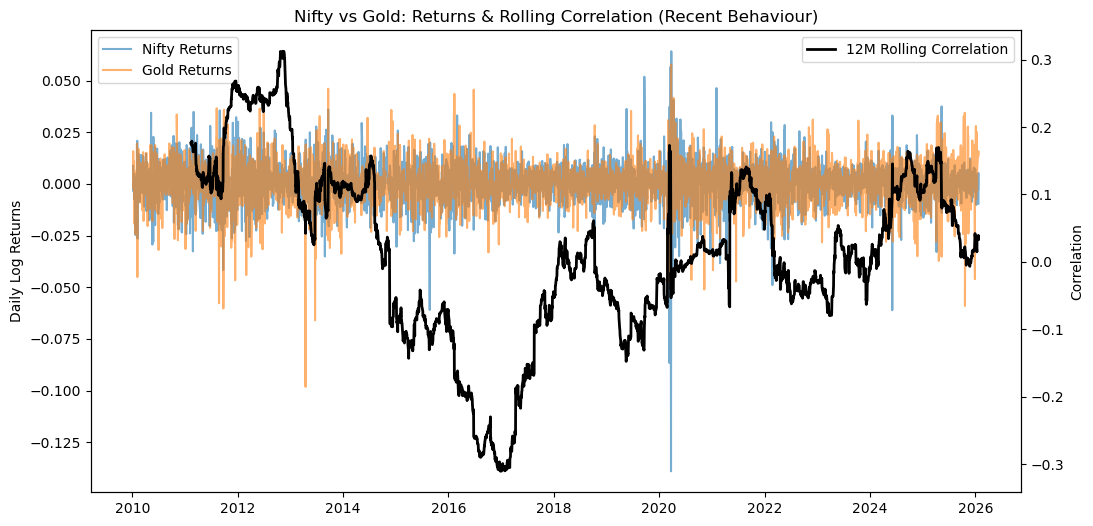

In [91]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot Nifty & Gold returns
ax1.plot(log_returns.index, log_returns['^NSEI'], label='Nifty Returns', alpha=0.6)
ax1.plot(log_returns.index, log_returns['GC=F'], label='Gold Returns', alpha=0.6)
ax1.set_ylabel('Daily Log Returns')
ax1.legend(loc='upper left')

# Secondary axis for correlation
ax2 = ax1.twinx()
ax2.plot(rolling_corr.index, rolling_corr, color='black', linewidth=2,
         label='12M Rolling Correlation')
ax2.set_ylabel('Correlation')
ax2.legend(loc='upper right')

plt.title('Nifty vs Gold: Returns & Rolling Correlation (Recent Behaviour)')
plt.show()


In [95]:
from plotly.offline import plot
import plotly.graph_objects as go

fig = go.Figure()

# Nifty returns
fig.add_trace(go.Scatter(
    x=log_returns.index,
    y=log_returns['^NSEI'],
    name='Nifty Returns',
    opacity = 0.6
))

# Gold returns
fig.add_trace(go.Scatter(
    x=log_returns.index,
    y=log_returns['GC=F'],
    name='Gold Returns',
    opacity = 0.6
))

# Rolling correlation (secondary axis)
fig.add_trace(go.Scatter(
    x=rolling_corr.index,
    y=rolling_corr,
    name='12M Rolling Correlation',
    yaxis='y2',
    line=dict(color='black', width=2)
))

fig.update_layout(
    title='Nifty vs Gold: Returns & Rolling Correlation (Recent Behaviour)',
    yaxis=dict(title='Daily Log Returns'),
    yaxis2=dict(
        title='Correlation',
        overlaying='y',
        side='right'
    ),
    template='plotly_white'
)

plot(fig)


'temp-plot.html'